# CSC_52082_EP - Semantic Similarity and Information Extraction

## 1. Semantic similarity

In this part we will get familiar with the NLTK WordNet interface and its semantic similarity measures. We will also learn to use gensim to create hierarchical Poincaré embeddings.

First of all, we need to import the WordNet library:

In [6]:
from nltk.corpus import wordnet as wn

Now we can use the *synsets* method to obtain all the synsets associated to a word (or, to be more precise, a *lemma*)

In [9]:
car_synsets = wn.synsets('car')

car_synsets

[Synset('car.n.01'),
 Synset('car.n.02'),
 Synset('car.n.03'),
 Synset('car.n.04'),
 Synset('cable_car.n.01')]

Note about lemmatization:
The wn.synsets() method apply lemmatization, so if you write wn.synsets(‘women’) it will return synsets for ‘woman’. Explicit lemmatization (when needed) can be done using the WordNetLemmatizer:


In [11]:
from nltk.stem import WordNetLemmatizer 
wnl = WordNetLemmatizer()
wnl.lemmatize('running', wn.VERB)
# You need to specify the POS tag. The default is 'noun'.


'run'

From a synset we can obtain its definition and the synsets that are related to itself:

In [12]:
for car in car_synsets:
    print ("definition: ", car.definition())
    print ("hypernyms:", car.hypernyms())
    print ("hyponyms:", car.hyponyms())


definition:  a motor vehicle with four wheels; usually propelled by an internal combustion engine
hypernyms: [Synset('motor_vehicle.n.01')]
hyponyms: [Synset('electric.n.01'), Synset('loaner.n.02'), Synset('minicar.n.01'), Synset('hot_rod.n.01'), Synset('compact.n.03'), Synset('cruiser.n.01'), Synset('hatchback.n.01'), Synset('sedan.n.01'), Synset('sports_car.n.01'), Synset('hardtop.n.01'), Synset('stock_car.n.01'), Synset('model_t.n.01'), Synset('cab.n.03'), Synset('racer.n.02'), Synset('minivan.n.01'), Synset('limousine.n.01'), Synset('used-car.n.01'), Synset('bus.n.04'), Synset('sport_utility.n.01'), Synset('horseless_carriage.n.01'), Synset('ambulance.n.01'), Synset('roadster.n.01'), Synset('convertible.n.01'), Synset('gas_guzzler.n.01'), Synset('subcompact.n.01'), Synset('stanley_steamer.n.01'), Synset('touring_car.n.01'), Synset('beach_wagon.n.01'), Synset('coupe.n.01'), Synset('pace_car.n.01'), Synset('jeep.n.01')]
definition:  a wheeled vehicle adapted to the rails of railroad


An interesting operation is to find the Least Common Subsumer with regard to another synset:

In [13]:
car = wn.synset("car.n.01")
car.lowest_common_hypernyms(wn.synset('bike.n.01'))


[Synset('motor_vehicle.n.01')]

We can calculate the (Wu-Palmer) semantic similarity between two synsets:

In [14]:
car.wup_similarity(wn.synset('bike.n.01'))

0.9166666666666666

To calculate the Lin semantic similarity, we need Information Content estimation from a corpus. NLTK contains some IC estimations from known corpora (like SemCor).

In [17]:
from nltk.corpus import wordnet_ic

semcor_ic = wordnet_ic.ic('ic-semcor.dat')

car.lin_similarity(wn.synset('bike.n.01'),semcor_ic)

1.3619865582086627e-299

For a coverage of the full list of methods available for the Synset class, you can look <A href="http://www.nltk.org/_modules/nltk/corpus/reader/wordnet.html">here</A>.

**Exercise 1**: in the file *word_list.tsv* you will find a list of 10 pairs of nouns. We would like to calculate their similarities according to Wu-Palmer and Lin measures (use IC from SemCor).

Note: since words may have multiple senses, we define the similarity between two words $v$, $w$ as:
$$ s(v, w) = \max_{s_i \in S_v, s_j \in S_w} sim(s_i, s_j)$$
where $S_v$ and $S_w$ are the set of synsets obtained from WordNet for word $v$ and word $w$, respectively.

In [26]:
import pandas as pd

def get_word_similarity(word1, word2, measure='wup'):
    """
    Calcule la similarité maximale entre deux mots selon la formule :
    s(v, w) = max [ sim(si, sj) ] pour si dans Sv, sj dans Sw
    """
    synsets1 = wn.synsets(word1, pos=wn.NOUN)
    synsets2 = wn.synsets(word2, pos=wn.NOUN)
    
    if not synsets1 or not synsets2:
        return 0.0
    
    max_sim = -1.0
    
    for s1 in synsets1:
        for s2 in synsets2:
            if measure == 'wup':
                sim = s1.wup_similarity(s2)
            elif measure == 'lin':
                # Lin nécessite l'IC et les deux synsets doivent être dans le même domaine (POS)
                try:
                    sim = s1.lin_similarity(s2, semcor_ic)
                except: # Gère les cas où les synsets ne partagent pas une racine commune
                    sim = 0.0
            
            if sim is not None and sim > max_sim:
                max_sim = sim
                
    return max_sim if max_sim != -1.0 else 0.0

df = pd.read_csv('word_list.tsv', sep=r'\s+', header=None, names=['word1', 'word2'])
print(f"{'Word 1':<15} | {'Word 2':<15} | {'Wu-Palmer':<10} | {'Lin':<10}")
print("-" * 60)

for _, row in df.iterrows():
    w1, w2 = str(row['word1']), str(row['word2'])
    wup = get_word_similarity(w1, w2, 'wup')
    lin = get_word_similarity(w1, w2, 'lin')
    print(f"{w1:<15} | {w2:<15} | {wup:10.4f} | {lin:10.4f}")

Word 1          | Word 2          | Wu-Palmer  | Lin       
------------------------------------------------------------
man             | tiger           |     0.7586 |     0.5755
base            | method          |     0.4762 |     0.3811
theory          | lady            |     0.1429 |    -0.0000
composition     | picture         |     0.8000 |     0.6053
cut             | portion         |     0.9231 |     0.7486
screen          | window          |     0.9000 |     0.4263
chair           | leg             |     0.8421 |     0.3825
sky             | airplane        |     0.2105 |     0.0780
terrain         | vehicle         |     0.5000 |     0.1408
salt            | sugar           |     0.8421 |     0.8304


### 1.1 Poincaré Embeddings

In this section we will build Poincaré embeddings from WordNet using the gensim <A HREF="https://radimrehurek.com/gensim/models/poincare.html">poincare</A> module.

A model can be trained from a list of pairs ( hyponym, hypernym):

In [29]:
from gensim.models.poincare import PoincareModel

relations = [('kangaroo', 'marsupial'), ('kangaroo', 'mammal'), ('gib', 'cat')]
model = PoincareModel(relations, negative=2)
model.train(epochs=50)

We can then calculate distances and similarities between the concepts in the ontology

In [30]:
model.kv.distance("kangaroo", "mammal")

0.04533720069330365

In [31]:
model.kv.similarity("kangaroo", "mammal")

0.9566291138751836

In [32]:
model.kv.most_similar("kangaroo")

[('kangaroo', 0.0),
 ('mammal', 0.04533720069330365),
 ('marsupial', 0.049042490316521886),
 ('cat', 1.479964756967585),
 ('gib', 1.516236960474092)]

**Exercise 2**: Train Poincaré embeddings from WordNet and calculate the similarities over the words as in the previous exercise. To facilitate the task, you will find the closure of WordNet noun relations in the file *noun_closure.tsv*. This can be loaded into the model as follows (**warning: long waiting time**):

In [33]:
from gensim.models.poincare import PoincareModel, PoincareRelations
from gensim.test.utils import datapath
import os

file_path = datapath(os.path.abspath('noun_closure.tsv'))
model = PoincareModel(PoincareRelations(file_path), negative=2)
model.train(epochs=2)


In [34]:
def get_poincare_similarity(word1, word2, model):
    s1 = wn.synsets(word1, pos=wn.NOUN)
    s2 = wn.synsets(word2, pos=wn.NOUN)
    
    if not s1 or not s2:
        return 0.0
    
    syn1_name = s1[0].name()
    syn2_name = s2[0].name()
    
    try:
        return model.kv.similarity(syn1_name, syn2_name)
    except KeyError:
        return 0.0

print(f"{'Word 1':<15} | {'Word 2':<15} | {'Poincaré Sim':<10}")
print("-" * 50)

for _, row in df.iterrows():
    w1, w2 = str(row['word1']), str(row['word2'])
    p_sim = get_poincare_similarity(w1, w2, model)
    print(f"{w1:<15} | {w2:<15} | {p_sim:10.4f}")

Word 1          | Word 2          | Poincaré Sim
--------------------------------------------------
man             | tiger           |     0.7065
base            | method          |     0.4468
theory          | lady            |     0.3561
composition     | picture         |     0.5046
cut             | portion         |     0.5412
screen          | window          |     0.7845
chair           | leg             |     0.4190
sky             | airplane        |     0.3744
terrain         | vehicle         |     0.4029
salt            | sugar           |     0.5350


**Exercise 3**: Now, calculate the distances between the words in the above list using word2vec vectors (available from <A HREF="https://radimrehurek.com/gensim/models/word2vec.html">Gensim</A>).

In [35]:
import gensim.downloader

w2v_model = gensim.downloader.load('word2vec-google-news-300')


[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [36]:
def get_w2v_distance(word1, word2, model):
    try:
        # La distance est définie comme (1 - similarité cosinus)
        return model.distance(word1.lower(), word2.lower())
    except KeyError:
        # Si un mot n'est pas présent dans le vocabulaire de Google News
        return 1.0 

print(f"{'Word 1':<15} | {'Word 2':<15} | {'W2V Distance':<10}")
print("-" * 50)

w2v_distances = []
for _, row in df.iterrows():
    w1, w2 = str(row['word1']), str(row['word2'])
    dist = get_w2v_distance(w1, w2, w2v_model)
    w2v_distances.append(dist)
    print(f"{w1:<15} | {w2:<15} | {dist:10.4f}")

Word 1          | Word 2          | W2V Distance
--------------------------------------------------
man             | tiger           |     0.8078
base            | method          |     0.9277
theory          | lady            |     0.9799
composition     | picture         |     0.7617
cut             | portion         |     0.8640
screen          | window          |     0.6696
chair           | leg             |     0.8662
sky             | airplane        |     0.7694
terrain         | vehicle         |     0.6956
salt            | sugar           |     0.5712


**Exercise 4**: compare the distances calculated using all the previous method, in particular try to find if exist a correlation between some of the measures (you can use Pearson correlation from <A HREF="https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html">numpy.corrcoef</A>)

In [37]:
import numpy as np


wup_scores = []
lin_scores = []
poincare_scores = []
w2v_scores = []

for _, row in df.iterrows():
    w1, w2 = str(row['word1']), str(row['word2'])
    
    wup_scores.append(get_word_similarity(w1, w2, 'wup'))
    lin_scores.append(get_word_similarity(w1, w2, 'lin'))
    poincare_scores.append(get_poincare_similarity(w1, w2, model)) 
    w2v_scores.append(get_w2v_distance(w1, w2, w2v_model))        

data_matrix = np.array([wup_scores, lin_scores, poincare_scores, w2v_scores])

corr_matrix = np.corrcoef(data_matrix)

labels = ["Wu-Palmer", "Lin", "Poincaré", "Word2Vec (Dist)"]

print(f"{'Correlation Matrix':<18}")
print("-" * 90)
print(f"{'':<18}", end="")
for label in labels:
    print(f"{label:>18}", end="")
print("\n")

for i, row_label in enumerate(labels):
    print(f"{row_label:<18}", end="")
    for j in range(len(labels)):
        print(f"{corr_matrix[i, j]:18.4f}", end="")
    print()

Correlation Matrix
------------------------------------------------------------------------------------------
                           Wu-Palmer               Lin          Poincaré   Word2Vec (Dist)

Wu-Palmer                     1.0000            0.8508            0.6776           -0.4233
Lin                           0.8508            1.0000            0.5536           -0.3924
Poincaré                      0.6776            0.5536            1.0000           -0.4062
Word2Vec (Dist)              -0.4233           -0.3924           -0.4062            1.0000


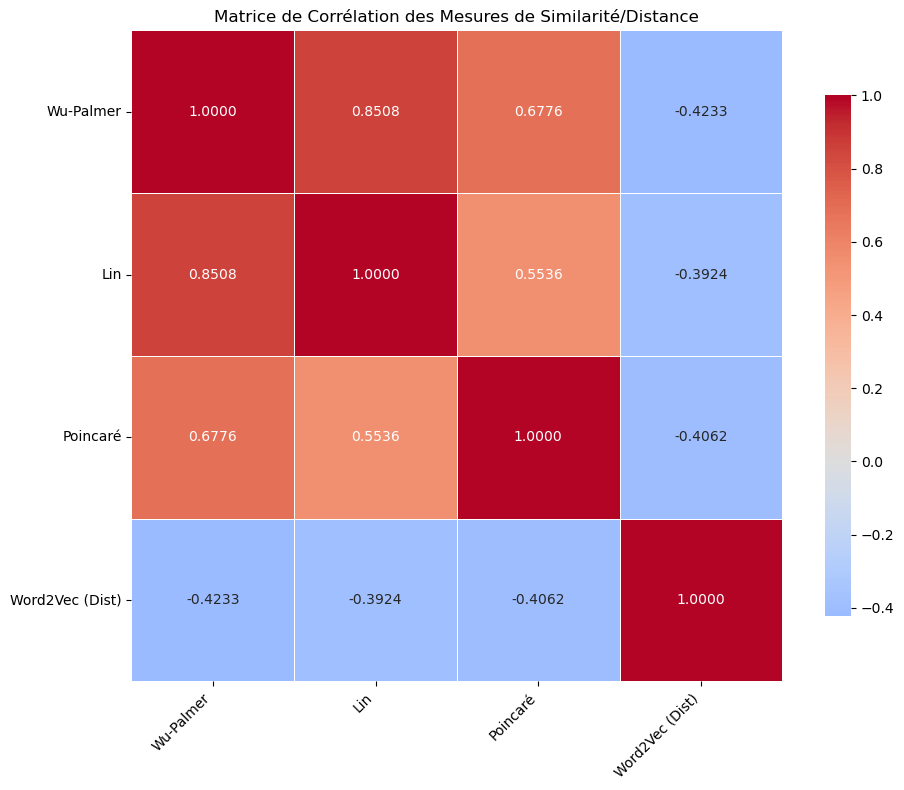

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(corr_matrix, labels):
    """
    Génère et sauvegarde une heatmap de la matrice de corrélation.
    """
    plt.figure(figsize=(10, 8))
    
    # Création de la heatmap avec seaborn
    sns.heatmap(
        corr_matrix, 
        annot=True,           # Affiche les valeurs numériques
        fmt=".4f",            # Format à 4 décimales
        xticklabels=labels, 
        yticklabels=labels, 
        cmap='coolwarm',      # Palette de couleurs divergente (Bleu < 0 < Rouge)
        center=0,             # Centre la palette sur 0
        square=True,          # Cellules carrées
        linewidths=.5,        # Lignes de séparation
        cbar_kws={"shrink": .8}
    )
    
    plt.title('Matrice de Corrélation des Mesures de Similarité/Distance')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig('correlation_heatmap.png')

plot_correlation_heatmap(corr_matrix, labels)

## 2. Implementing Knowledge Graph Embeddings (TransE)

Model Definition (TransE): $$ h+r \approx t$$

Scoring Function: $$f_r(h,t)=||h+r−t||_p$$ where $p$ may be 1 (L1-norm) or 2 (L2-norm)

Loss: $$
\mathcal{L} =
\sum_{(h,r,t)\in\mathcal{S}}
\sum_{(h',r,t')\in\mathcal{S}'}
\max\!\big(0,\; \gamma + f_r(h,t) - f_r(h',t')\big)$$

Where:

$S$ positive triples ; $S'$ corrupted triples and $\gamma$ is the margin.

We are going to work on the WordNet18RR (WN18RR) dataset. Here are some auxiliary functions to load the data:

In [39]:
import os

def read_triple_file(path):
    triples = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 3:
                continue
            h, r, t = parts
            triples.append((h, r, t))
    return triples


def load_wn18rr(data_dir):
    train_path = os.path.join(data_dir, "train.txt")
    valid_path = os.path.join(data_dir, "valid.txt")
    test_path  = os.path.join(data_dir, "test.txt")

    train_triples = read_triple_file(train_path)
    valid_triples = read_triple_file(valid_path)
    test_triples  = read_triple_file(test_path)

    return train_triples, valid_triples, test_triples

def build_mappings(train, valid, test):
    entities = set()
    relations = set()

    for dataset in [train, valid, test]:
        for h, r, t in dataset:
            entities.add(h)
            entities.add(t)
            relations.add(r)

    entity2id = {e: i for i, e in enumerate(sorted(entities))}
    relation2id = {r: i for i, r in enumerate(sorted(relations))}

    return entity2id, relation2id

def index_triples(triples, entity2id, relation2id):
    return [
        (entity2id[h], relation2id[r], entity2id[t])
        for (h, r, t) in triples
    ]

In [40]:
data_dir = "WN18RR"

train_raw, valid_raw, test_raw = load_wn18rr(data_dir)

entity2id, relation2id = build_mappings(
    train_raw, valid_raw, test_raw
)

train = index_triples(train_raw, entity2id, relation2id)
valid = index_triples(valid_raw, entity2id, relation2id)
test  = index_triples(test_raw, entity2id, relation2id)

print("Entities:", len(entity2id))
print("Relations:", len(relation2id))
print("Train triples:", len(train))
print("Valid triples:", len(valid))
print("Test triples:", len(test))

Entities: 41105
Relations: 11
Train triples: 86835
Valid triples: 3034
Test triples: 3134


> **Exercise 5**: Complete the implementation of the TransE model here

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, dim=100, p_norm=1):
        super().__init__()
        self.dim = dim
        self.p_norm = p_norm

        self.entity_emb = nn.Embedding(num_entities, dim)
        self.relation_emb = nn.Embedding(num_relations, dim)

        nn.init.xavier_uniform_(self.entity_emb.weight.data)
        nn.init.xavier_uniform_(self.relation_emb.weight.data)

    def forward(self, h, r, t):
        h_emb = self.entity_emb(h)
        r_emb = self.relation_emb(r)
        t_emb = self.entity_emb(t)
        score = -torch.norm(h_emb + r_emb - t_emb, p=self.p_norm, dim=1)
        
        return score

    def normalize_entities(self):
        with torch.no_grad():
            self.entity_emb.weight.data = F.normalize(
                self.entity_emb.weight.data, p=2, dim=1
            )

> **Exercise 6**: Implement the negative sampling function. 50% of times we change the head, 50% of times we change the tail

In [47]:
def generate_negative(triples, num_entities):
    corrupted = []
    for h, r, t in triples:
        if torch.rand(1).item() < 0.5:
            # Corruption de la tête
            h_corrupted = torch.randint(0, num_entities, (1,)).item()
            corrupted.append((h_corrupted, r, t))
        else:
            # Corruption de la queue
            t_corrupted = torch.randint(0, num_entities, (1,)).item()
            corrupted.append((h, r, t_corrupted))
            
    return corrupted

In [48]:
from tqdm import tqdm

def train_transe(model, train_triples, valid_triples,
                 num_entities,
                 epochs=100,
                 batch_size=1024,
                 lr=0.001,
                 margin=1.0,
                 device="cpu"):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MarginRankingLoss(margin=margin)
    
    triple_set = set(train_triples) | set(valid_triples)
    train_tensor = torch.tensor(train_triples)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(train_tensor))
        total_loss = 0

        for i in range(0, len(train_tensor), batch_size):
            batch = train_tensor[perm[i:i+batch_size]].tolist()
            neg_batch = torch.tensor(
                generate_negative(batch, num_entities)
            )
            
            batch = torch.tensor(batch).to(device)
            neg_batch = torch.tensor(neg_batch).to(device)

            h, r, t = batch[:,0], batch[:,1], batch[:,2]
            h_n, r_n, t_n = neg_batch[:,0], neg_batch[:,1], neg_batch[:,2]

            pos_score = model(h, r, t)
            neg_score = model(h_n, r_n, t_n)

            target = -torch.ones_like(pos_score)
            loss = criterion(pos_score, neg_score, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            model.normalize_entities()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

You can use the following code to evaluate the results of training

In [49]:
def evaluate(model, test_triples, all_triples,
             num_entities, device="cpu"):

    model.eval()
    ranks = []

    all_triple_set = set(all_triples)

    with torch.no_grad():
        for h, r, t in tqdm(test_triples):

            # Tail prediction
            h_tensor = torch.tensor([h]*num_entities).to(device)
            r_tensor = torch.tensor([r]*num_entities).to(device)
            t_candidates = torch.arange(num_entities).to(device)

            scores = model(h_tensor, r_tensor, t_candidates)

            # Filter
            for e in range(num_entities):
                if (h, r, e) in all_triple_set and e != t:
                    scores[e] = 1e6

            rank = torch.argsort(scores).tolist().index(t) + 1
            ranks.append(rank)

            # Head prediction
            h_candidates = torch.arange(num_entities).to(device)
            t_tensor = torch.tensor([t]*num_entities).to(device)
            r_tensor = torch.tensor([r]*num_entities).to(device)

            scores = model(h_candidates, r_tensor, t_tensor)

            for e in range(num_entities):
                if (e, r, t) in all_triple_set and e != h:
                    scores[e] = 1e6

            rank = torch.argsort(scores).tolist().index(h) + 1
            ranks.append(rank)

    ranks = torch.tensor(ranks, dtype=torch.float)

    mrr = torch.mean(1.0 / ranks).item()
    hits1 = torch.mean((ranks <= 1).float()).item()
    hits3 = torch.mean((ranks <= 3).float()).item()
    hits10 = torch.mean((ranks <= 10).float()).item()

    print(f"MRR: {mrr:.4f}")
    print(f"Hits@1: {hits1:.4f}")
    print(f"Hits@3: {hits3:.4f}")
    print(f"Hits@10: {hits10:.4f}")

    return mrr, hits10

In [52]:
import torch, random

device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    dim=200,
    p_norm=1
)

train_transe(model,
             train,
             valid,
             num_entities=len(entity2id),
             epochs=60,
             batch_size=1024,
             lr=0.001,
             margin=1.0,
             device=device)



C:\Users\Alexander\AppData\Local\Temp\ipykernel_35248\95510107.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  neg_batch = torch.tensor(neg_batch).to(device)


Epoch 1 | Loss: 89.0229
Epoch 2 | Loss: 54.1554
Epoch 3 | Loss: 33.2862
Epoch 4 | Loss: 22.0418
Epoch 5 | Loss: 15.5600
Epoch 6 | Loss: 11.5979
Epoch 7 | Loss: 8.9843
Epoch 8 | Loss: 7.2051
Epoch 9 | Loss: 5.8180
Epoch 10 | Loss: 4.7520
Epoch 11 | Loss: 4.1982
Epoch 12 | Loss: 3.4544
Epoch 13 | Loss: 3.2071
Epoch 14 | Loss: 2.8146
Epoch 15 | Loss: 2.5379
Epoch 16 | Loss: 2.3349
Epoch 17 | Loss: 2.0950
Epoch 18 | Loss: 1.8762
Epoch 19 | Loss: 1.7751
Epoch 20 | Loss: 1.6652
Epoch 21 | Loss: 1.5554
Epoch 22 | Loss: 1.4884
Epoch 23 | Loss: 1.4383
Epoch 24 | Loss: 1.3217
Epoch 25 | Loss: 1.2538
Epoch 26 | Loss: 1.2581
Epoch 27 | Loss: 1.1803
Epoch 28 | Loss: 1.1761
Epoch 29 | Loss: 1.0755
Epoch 30 | Loss: 1.0480
Epoch 31 | Loss: 0.9853
Epoch 32 | Loss: 0.9810
Epoch 33 | Loss: 0.9842
Epoch 34 | Loss: 0.9895
Epoch 35 | Loss: 0.8771
Epoch 36 | Loss: 0.8997
Epoch 37 | Loss: 0.8775
Epoch 38 | Loss: 0.8682
Epoch 39 | Loss: 0.8574
Epoch 40 | Loss: 0.8262
Epoch 41 | Loss: 0.8067
Epoch 42 | Loss: 0.

In [53]:
all_triples = train + valid + test

evaluate(model,
         test,
         all_triples,
         num_entities=len(entity2id),
         device=device)



  0%|          | 0/3134 [00:00<?, ?it/s]

100%|██████████| 3134/3134 [01:44<00:00, 29.99it/s]

MRR: 0.0581
Hits@1: 0.0337
Hits@3: 0.0635
Hits@10: 0.1047


(0.058091357350349426, 0.1046585813164711)